# Customer Demographics Study
Exploring age, gender, location, education, income, and spending patterns
across 2,500 customers to understand who the customer base really is.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
df = pd.read_csv("../data/customer_data.csv")
df.head()

,CustomerID,Age,Gender,City,Education,IncomeBracket,AnnualSpend,MembershipTier,TenureMonths,TotalOrders
0,C1000,52,Other,Hyderabad,Bachelor's,50k-100k,17152.26,Silver,5,6
1,C1001,30,Female,Delhi,Master's,100k-200k,30274.28,Basic,39,9
2,C1002,45,Female,Delhi,Bachelor's,50k-100k,16032.76,Basic,28,6
3,C1003,18,Male,Hyderabad,Bachelor's,<25k,3731.09,Silver,13,1
4,C1004,36,Female,Ahmedabad,Master's,200k+,57617.21,Silver,9,19


## Dataset Overview

In [2]:
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   CustomerID      2500 non-null   str    
 1   Age             2500 non-null   int64  
 2   Gender          2500 non-null   str    
 3   City            2500 non-null   str    
 4   Education       2500 non-null   str    
 5   IncomeBracket   2500 non-null   str    
 6   AnnualSpend     2500 non-null   float64
 7   MembershipTier  2500 non-null   str    
 8   TenureMonths    2500 non-null   int64  
 9   TotalOrders     2500 non-null   int64  
dtypes: float64(1), int64(3), str(6)
memory usage: 195.4 KB


,Age,AnnualSpend,TenureMonths,TotalOrders
count,2500.000000,2500.000000,2500.000000,2500.000000
mean,33.834400,20408.354172,29.631600,5.150400
std,10.034304,16767.151096,16.950481,4.667986
min,18.000000,500.000000,1.000000,1.000000
25%,26.000000,7988.140000,15.000000,2.000000
50%,33.000000,16181.575000,30.000000,4.000000
75%,41.000000,27342.312500,44.000000,7.000000
max,67.000000,104738.020000,59.000000,39.000000


## 1. Age Distribution

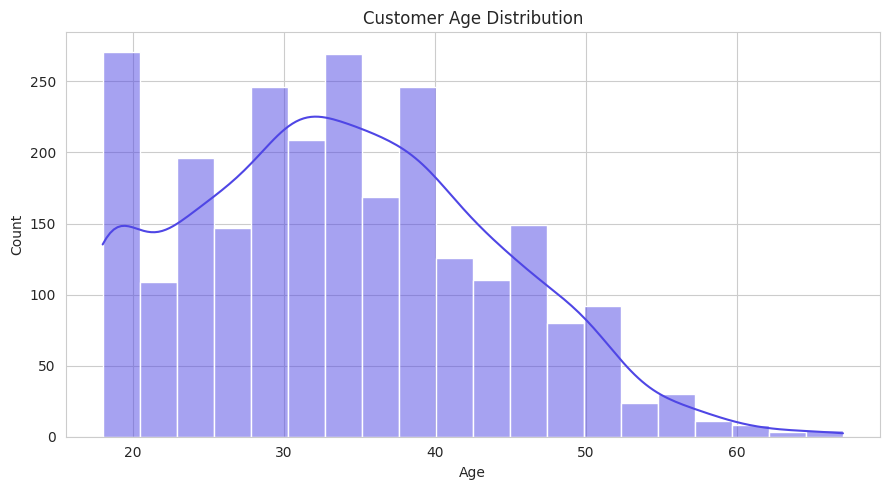

In [3]:
plt.figure(figsize=(9,5))
sns.histplot(df["Age"], bins=20, kde=True, color="#4F46E5")
plt.title("Customer Age Distribution")
plt.xlabel("Age")
plt.tight_layout()
plt.show()

## 2. Gender Split

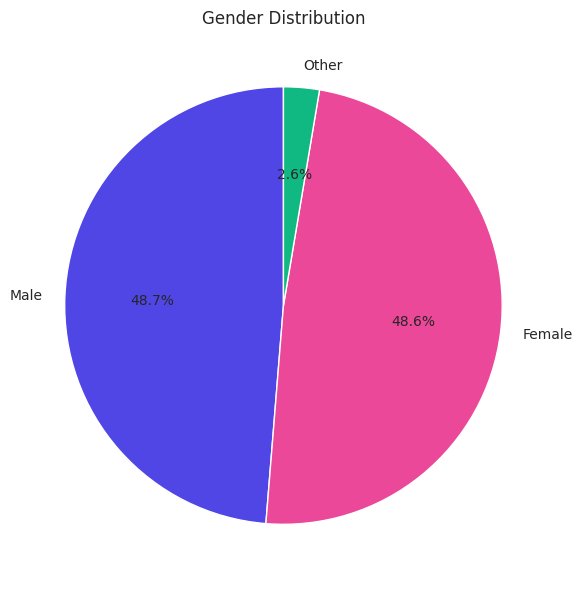

In [4]:
gender_counts = df["Gender"].value_counts()
plt.figure(figsize=(6,6))
plt.pie(gender_counts.values, labels=gender_counts.index, autopct="%1.1f%%",
        colors=["#4F46E5", "#EC4899", "#10B981"], startangle=90)
plt.title("Gender Distribution")
plt.tight_layout()
plt.show()

## 3. Customers by City

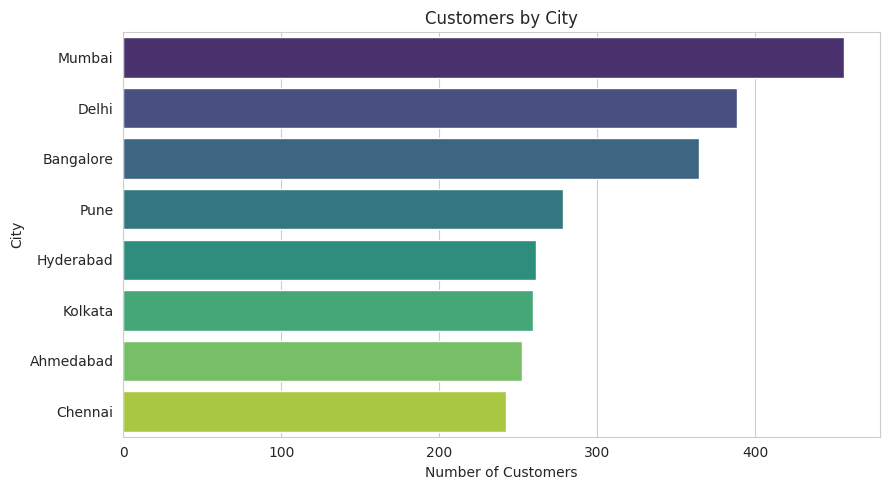

In [5]:
city_counts = df["City"].value_counts()
plt.figure(figsize=(9,5))
sns.barplot(x=city_counts.values, y=city_counts.index, hue=city_counts.index, palette="viridis", legend=False)
plt.title("Customers by City")
plt.xlabel("Number of Customers")
plt.tight_layout()
plt.show()

## 4. Income Bracket Distribution

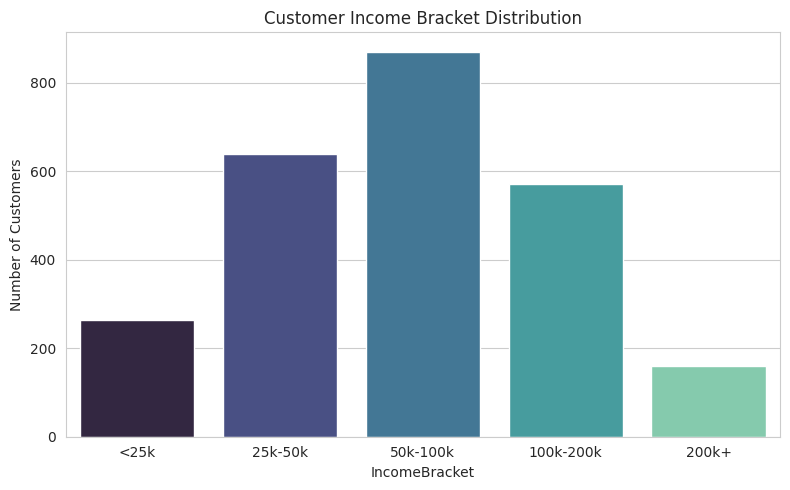

In [6]:
income_order = ["<25k", "25k-50k", "50k-100k", "100k-200k", "200k+"]
income_counts = df["IncomeBracket"].value_counts().reindex(income_order)
plt.figure(figsize=(8,5))
sns.barplot(x=income_counts.index, y=income_counts.values, hue=income_counts.index, palette="mako", legend=False)
plt.title("Customer Income Bracket Distribution")
plt.ylabel("Number of Customers")
plt.tight_layout()
plt.show()

## 5. Spend by Membership Tier

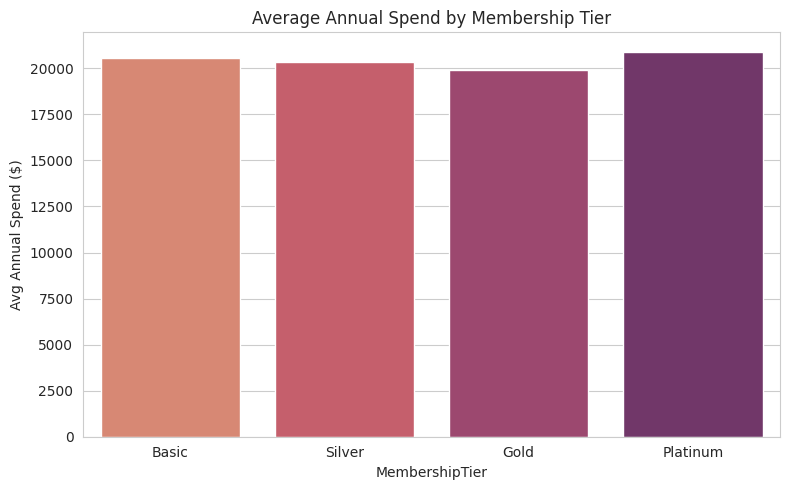

In [7]:
tier_order = ["Basic", "Silver", "Gold", "Platinum"]
tier_spend = df.groupby("MembershipTier")["AnnualSpend"].mean().reindex(tier_order)
plt.figure(figsize=(8,5))
sns.barplot(x=tier_spend.index, y=tier_spend.values, hue=tier_spend.index, palette="flare", legend=False)
plt.title("Average Annual Spend by Membership Tier")
plt.ylabel("Avg Annual Spend ($)")
plt.tight_layout()
plt.show()

## 6. Education vs Income

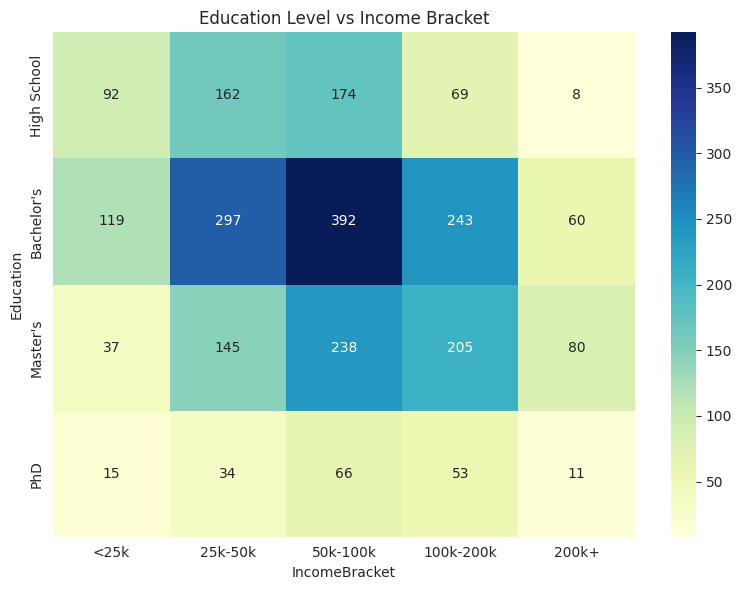

In [8]:
edu_order = ["High School", "Bachelor's", "Master's", "PhD"]
cross = pd.crosstab(df["Education"], df["IncomeBracket"]).reindex(edu_order)[income_order]
plt.figure(figsize=(8,6))
sns.heatmap(cross, annot=True, fmt="d", cmap="YlGnBu")
plt.title("Education Level vs Income Bracket")
plt.tight_layout()
plt.show()

## Key Insights
- The customer base averages **34 years old**, skewing toward a working-age population.
- Gender split is nearly even between Male and Female customers (~49% each).
- **Mumbai** has the largest customer concentration, followed by Delhi and Bangalore.
- Higher education levels (Master's, PhD) correlate with higher income brackets.
- **Platinum** tier members have the highest average annual spend, confirming
  membership tier is a strong proxy for customer value.